# STUDENT PERFORMANCE INDICATOR

### - Problem Statement
- This Project understands how a students performance is affected by other variables like Gender, Ethinicity, Perental level of education, Lunch and Test preperation cources.


### - Importing Neccessary Liberary

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [19]:
## Importing the data
df = pd.read_csv("data.csv")

In [21]:
## Taking the first five rows from the dataset
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [23]:
## Checking the datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [52]:
## Checking for any null values
df.isna().sum()  

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [56]:
## Checking for any duplicated values
df.duplicated().sum()

0

In [58]:
## Describing the numerical data
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [60]:
## Checking the unique values in columns
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### Insights

- We have 5 categorical columns and 3 continuous variables
- Mean and standard deviation of all the columns are pretty close 
- Maths has the lowest minimum marks at 0, followed by writting at 10 and reading at 17

## Exploring Data

In [292]:
## Counting values in object features

obj_col = df.select_dtypes(include='object').columns

for col in obj_col:
    print(f"\nColumn : {col}")
    print(df[col].value_counts())
    print('\n','-'*50)


Column : gender
gender
female    518
male      482
Name: count, dtype: int64

 --------------------------------------------------

Column : race_ethnicity
race_ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

 --------------------------------------------------

Column : parental_level_of_education
parental_level_of_education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

 --------------------------------------------------

Column : lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

 --------------------------------------------------

Column : test_preparation_course
test_preparation_course
none         642
completed    358
Name: count, dtype: int64

 --------------------------------------------------


In [294]:
## Counting values in object features in percentages

obj_col = df.select_dtypes(include='object').columns

for col in obj_col:
    print(f"\nColumn : {col}")
    print(df[col].value_counts(normalize=True)*100)
    print('\n','-'*50)


Column : gender
gender
female    51.8
male      48.2
Name: proportion, dtype: float64

 --------------------------------------------------

Column : race_ethnicity
race_ethnicity
group C    31.9
group D    26.2
group B    19.0
group E    14.0
group A     8.9
Name: proportion, dtype: float64

 --------------------------------------------------

Column : parental_level_of_education
parental_level_of_education
some college          22.6
associate's degree    22.2
high school           19.6
some high school      17.9
bachelor's degree     11.8
master's degree        5.9
Name: proportion, dtype: float64

 --------------------------------------------------

Column : lunch
lunch
standard        64.5
free/reduced    35.5
Name: proportion, dtype: float64

 --------------------------------------------------

Column : test_preparation_course
test_preparation_course
none         64.2
completed    35.8
Name: proportion, dtype: float64

 --------------------------------------------------


In [75]:
## Extracting Numerical columns

num_cols = [col for col in df.columns if df[col].dtype != 'O' ]
num_cols

['math_score', 'reading_score', 'writing_score']

In [77]:
## Adding Num_cols to get total_marks and average

df['total_score'] = df['math_score'] + df['writing_score'] + df['reading_score']
df['average'] = df['total_score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [91]:
math_full = df[df['math_score'] == 100]['average'].count()
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score'] == 100]['average'].count()
print('number of students who got full score in mathematics : ', math_full)
print('number of students who got full score in reading : ', reading_full)
print('number of students who got full score in writing : ', writing_full)

number of students who got full score in mathematics :  7
number of students who got full score in reading :  17
number of students who got full score in writing :  14


In [93]:
math_less_30= df[df['math_score'] <= 30]['average'].count()
reading_less_30= df[df['reading_score'] <= 30]['average'].count()
writing_less_30= df[df['writing_score'] <= 30]['average'].count()
print('number of students who got less than 30 in mathematics : ', math_less_30
    )
print('number of students who got less than 30 in reading : ', reading_less_30
    )
print('number of students who got less than 30 in writing : ', writing_less_30
    )

number of students who got less than 30 in mathematics :  16
number of students who got less than 30 in reading :  8
number of students who got less than 30 in writing :  10


In [196]:
df.groupby('gender')['average'].agg(['min','max','mean'])

,min,max,mean
gender,,,
female,9.0,100.0,69.569498
male,23.0,100.0,65.837483


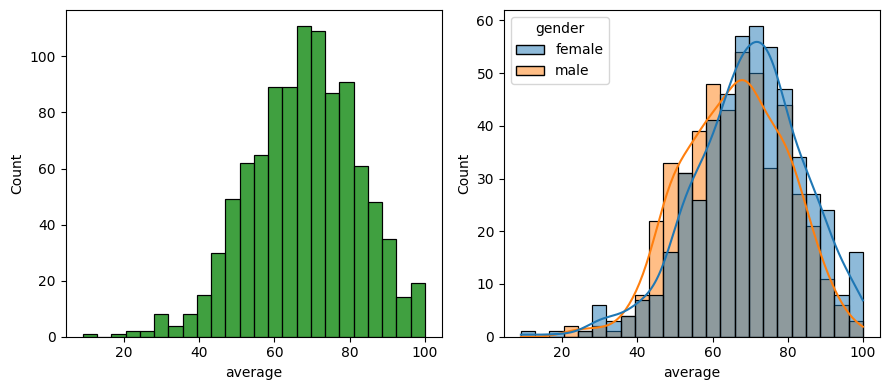

In [118]:
plt.figure(figsize= (9,4))
plt.subplot(121)
sns.histplot(df['average'],color='g')
plt.subplot(122)
sns.histplot(data = df, x= 'average',hue = 'gender',kde= True)
plt.tight_layout()
plt.show()

## Females are tend to perform better than male in math score

In [206]:
df.groupby(['race_ethnicity','gender']).size()

race_ethnicity  gender
group A         female     36
                male       53
group B         female    104
                male       86
group C         female    180
                male      139
group D         female    129
                male      133
group E         female     69
                male       71
dtype: int64

<Axes: xlabel='race_ethnicity', ylabel='count'>

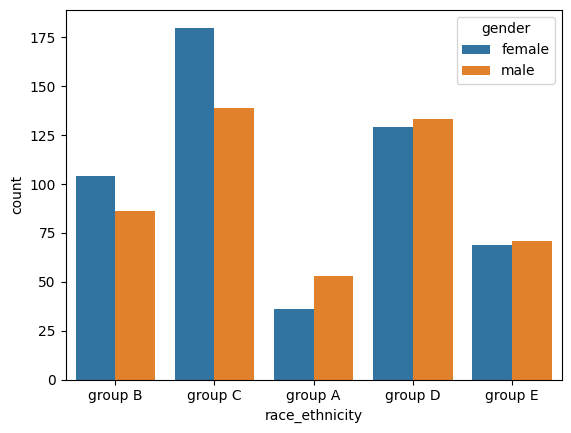

In [208]:
sns.countplot(data= df, x = 'race_ethnicity',hue = 'gender')

In [186]:
df.groupby('race_ethnicity')['average'].mean()

race_ethnicity
group A    62.992509
group B    65.468421
group C    67.131661
group D    69.179389
group E    72.752381
Name: average, dtype: float64

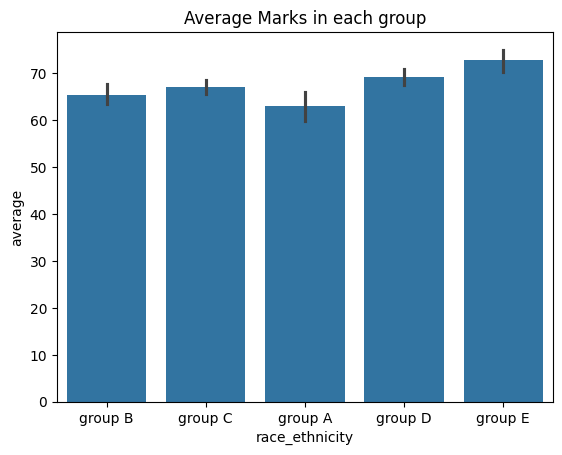

In [192]:
sns.barplot(data = df,
           x= 'race_ethnicity',
           y= 'average',
           estimator= 'mean'
           )
plt.title('Average Marks in each group')
plt.show()

In [268]:
df.groupby(['parental_level_of_education'])['average'].mean().sort_values(ascending = False)

parental_level_of_education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.569069
some college          68.476401
some high school      65.108007
high school           63.096939
Name: average, dtype: float64

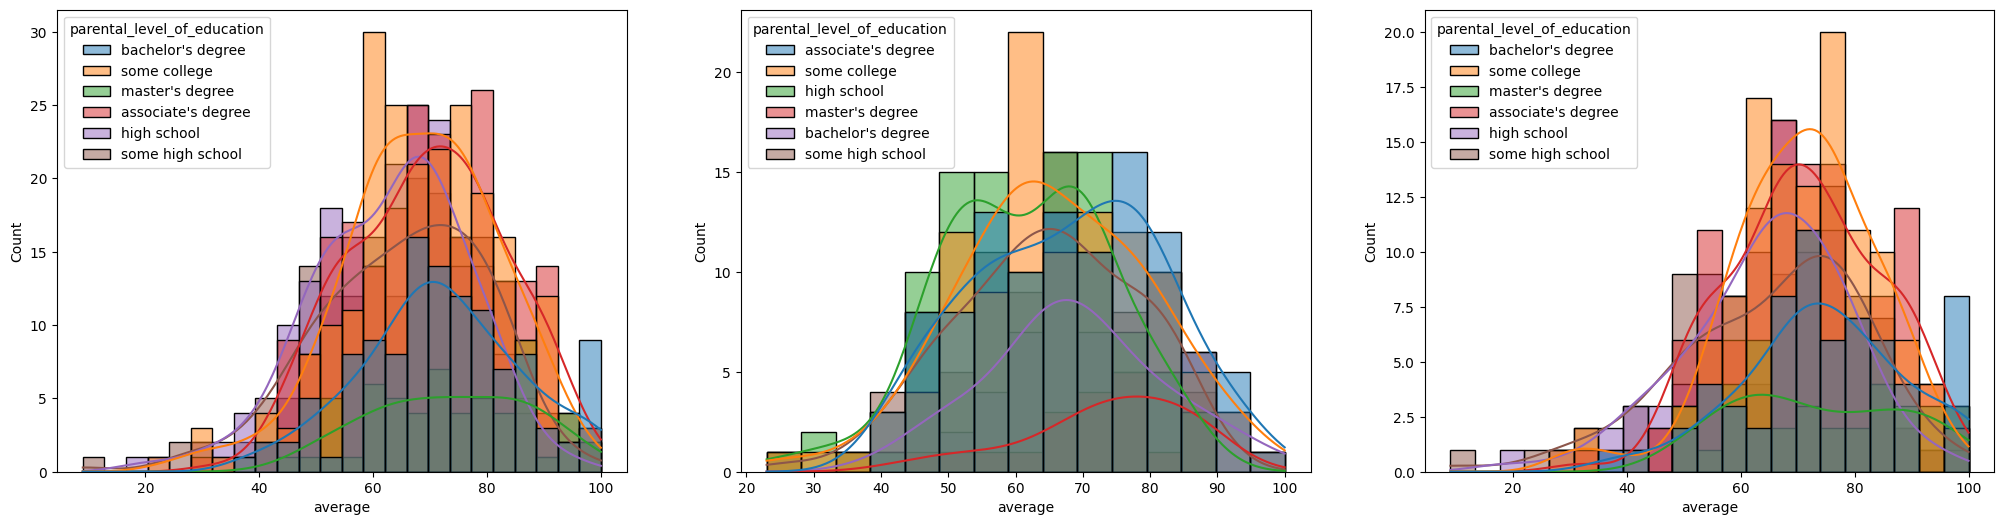

In [272]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(131)
ax =sns.histplot(data=df,x='average',kde=True,hue='parental_level_of_education')
plt.subplot(132)
ax =sns.histplot(data=df[df.gender=='male'],x='average',kde=True,hue='parental_level_of_education')
plt.subplot(133)
ax =sns.histplot(data=df[df.gender=='female'],x='average',kde=True,hue='parental_level_of_education')
plt.show()

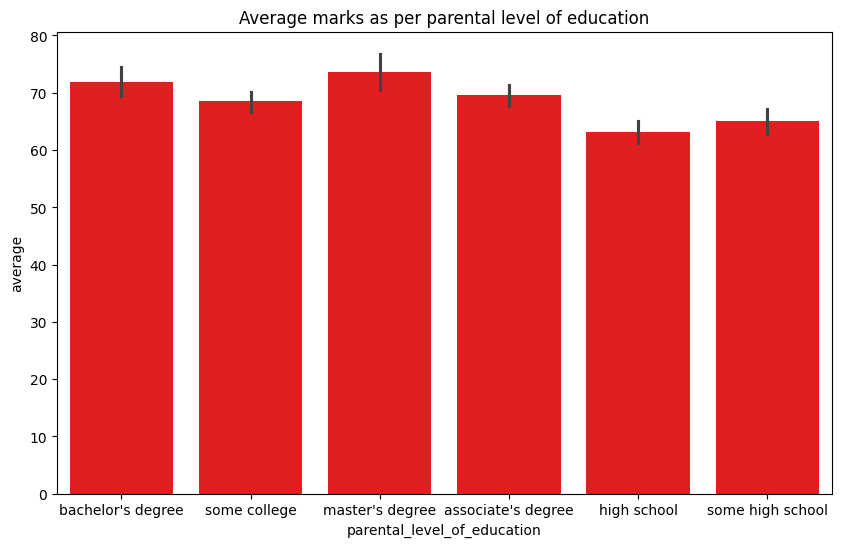

In [222]:
plt.figure(figsize=(10,6))
sns.barplot(data = df,
            x = 'parental_level_of_education',
            y = 'average',
            estimator='mean',
            color='r'
           )
plt.title('Average marks as per parental level of education')
plt.show()

In [230]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [234]:
df.groupby(['lunch','gender'])['average'].mean()

lunch         gender
free/reduced  female    63.215168
              male      61.042169
standard      female    73.219858
              male      68.356540
Name: average, dtype: float64

In [238]:
df.groupby(['gender','test_preparation_course'])['average'].mean()

gender  test_preparation_course
female  completed                  74.454710
        none                       66.878244
male    completed                  70.781609
        none                       63.044372
Name: average, dtype: float64

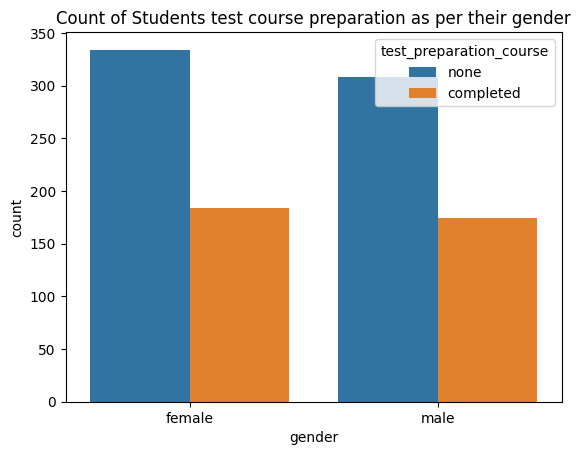

In [260]:
sns.countplot(
    data= df,
    x= 'gender',
    hue= 'test_preparation_course'    
)
plt.title('Count of Students test course preparation as per their gender')
plt.show()

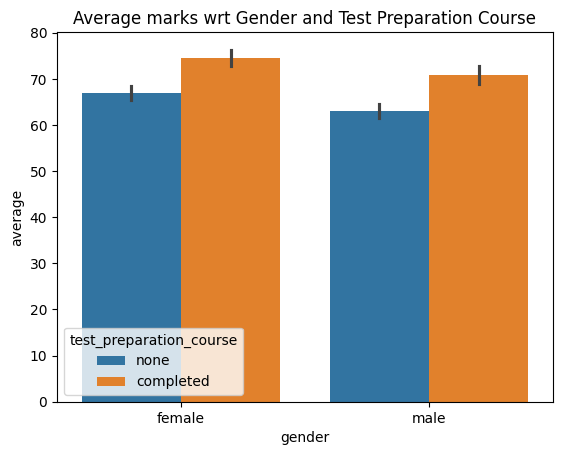

In [264]:
sns.barplot(
    data=df,
    x='gender',
    y='average',
    hue='test_preparation_course',
    estimator='mean'
)
plt.title('Average marks wrt Gender and Test Preparation Course')
plt.show()

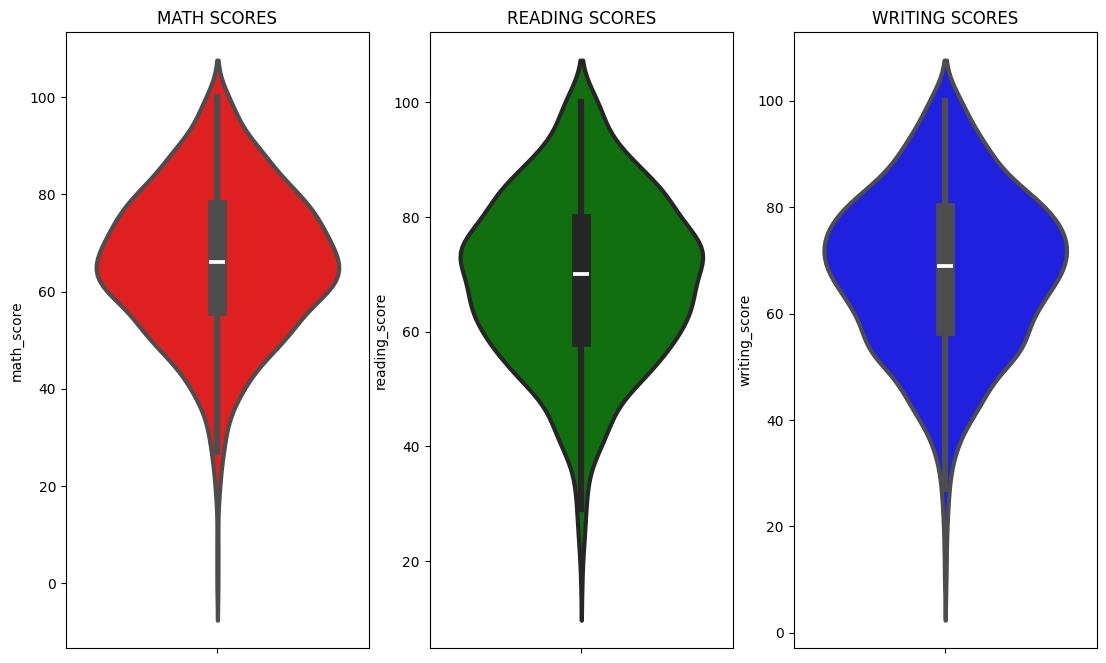

In [276]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

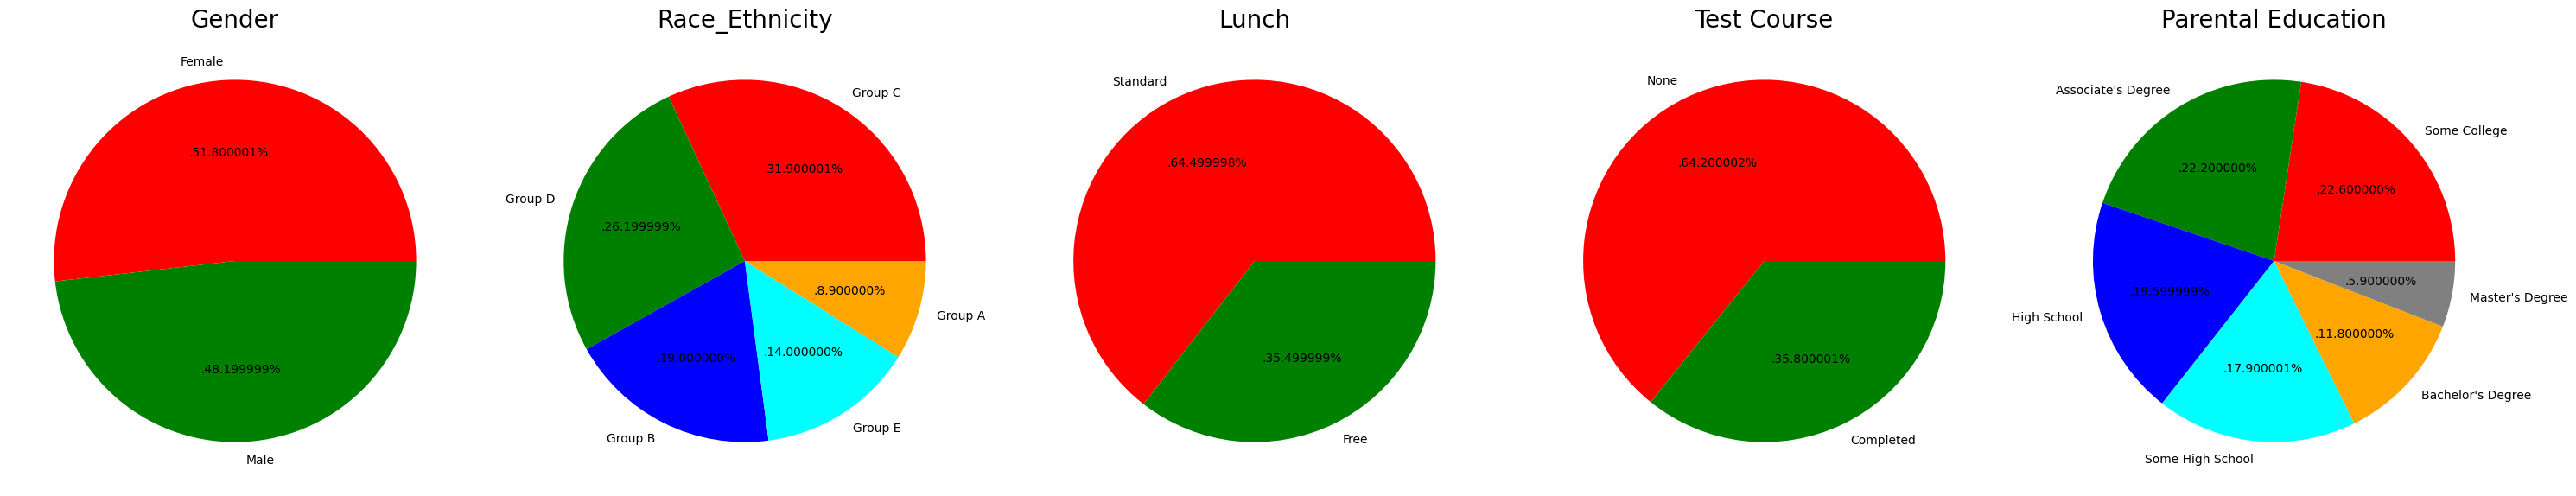

In [280]:
plt.rcParams['figure.figsize'] = (30, 20)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race_Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

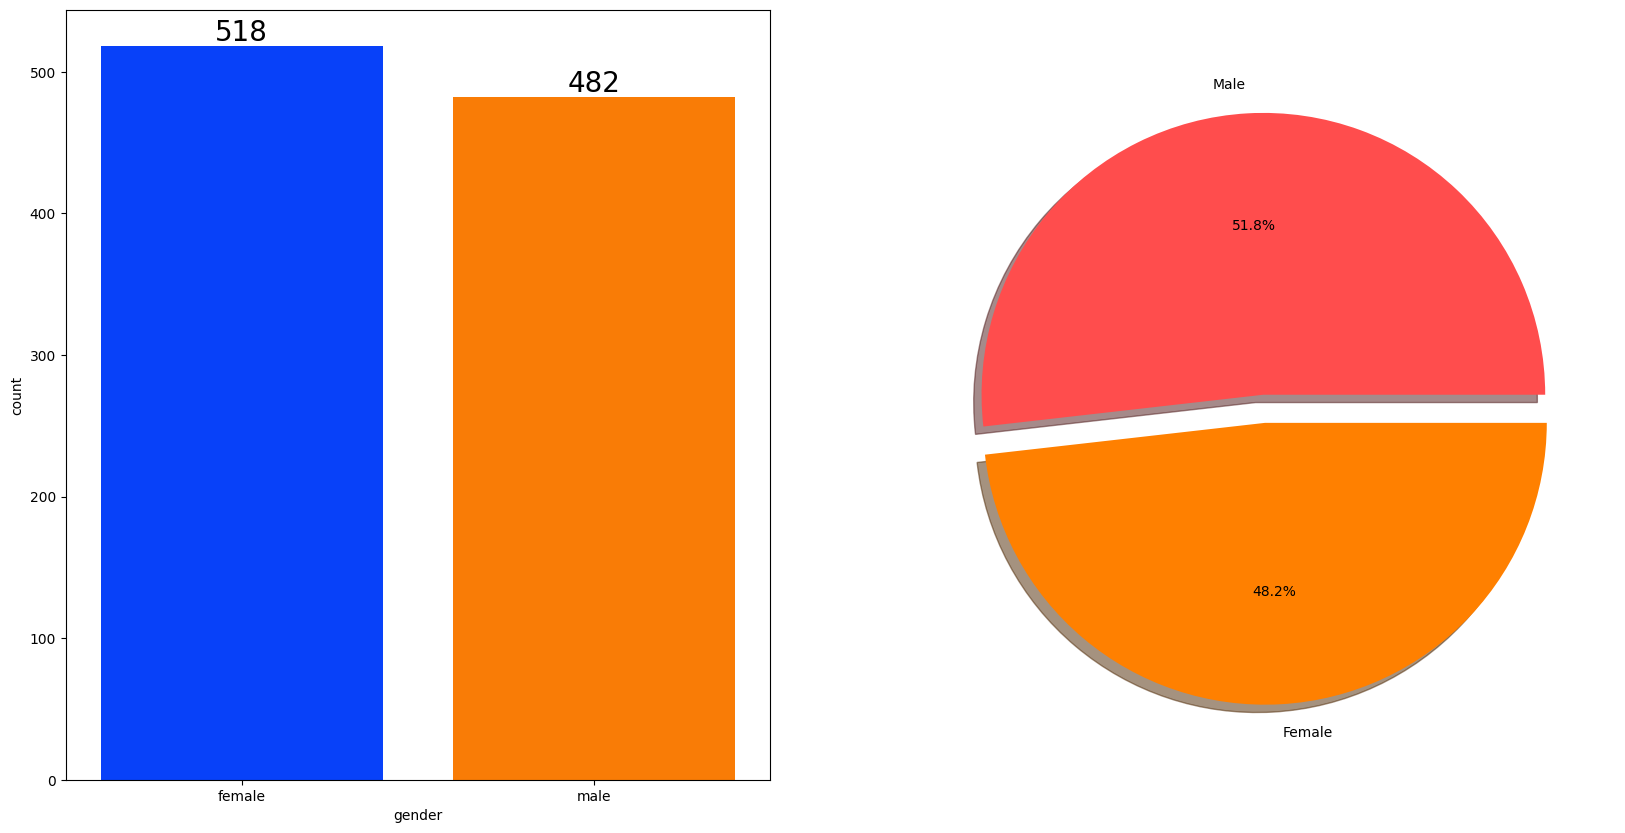

In [288]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['gender'],data=df,palette ='bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),labels=['Male','Female'],explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])
plt.show()